# Evaluating a Saved LightGBM Model on a Benign-Only Dataset

**Purpose.** Assess a saved LightGBM binary classifier on a benign-only domain dataset to understand **false positives**. We’ll compute metrics (incl. **False Positive Rate**), plot a 2×2 confusion matrix, and list false-positive domains.

**Inputs**
- **Model:** `models/malware_lgbm_model_nonndf.joblib`
- **Dataset:** `../testdata/xyz.parquet` (all rows benign)

**Outputs**
- Metrics: Accuracy, Precision, Recall, F1, **FPR**
- Confusion matrix figure
- Optional list/CSV of false-positive domains

**Assumptions**
- Target mapping: `{"benign": 0, "malware": 1}`
- Dataset is benign-only; we add the label column on load

**Notebook Roadmap**
1) Environment & versions  
2) Parameters (paths, constants)  
3) Imports  
4) Utilities (feature alignment, plotting)  
5) Load model & data  
6) Sanity checks & schema alignment  
7) Evaluate (metrics)  
8) Confusion matrix & FP listing  


## 1. Environment & versions

Record Python and key package versions for **reproducibility**. If results drift later, this cell helps pinpoint environment changes.


In [1]:
# Record environment for reproducibility
import sys, platform
import importlib

def pkg_ver(name):
    try:
        return importlib.import_module(name).__version__
    except Exception:
        return "not-installed"

print("Python:", sys.version.split()[0], "|", platform.platform())
for pkg in ["numpy", "pandas", "pyarrow", "scikit-learn", "lightgbm", "joblib", "matplotlib"]:
    print(f"{pkg}:", pkg_ver(pkg))

Python: 3.11.14 | Linux-6.14.0-33-generic-x86_64-with-glibc2.39
numpy: 1.24.4
pandas: 2.3.3
pyarrow: 17.0.0
scikit-learn: not-installed
lightgbm: 4.6.0
joblib: 1.5.2
matplotlib: 3.10.7


## 2. Parameters (single source of truth)

Centralize all configurable values (paths, label mapping, threshold, seeds) here. Update only this cell when rerunning on new data or models.


In [3]:
# --- Paths & constants ---
MODEL_PATH   = "models/malware_lgbm_model_nonndf.joblib"
FP_DATASET   = "../testdata/xyz.parquet"

CORRECT_LABEL = "benign"                 # all rows are benign
TARGET_MAP    = {"benign": 0, "malware": 1}   # << positive class is 'malware'

THRESHOLD     = 0.50                     # decision threshold for "malware"
TOP_N_FP_LIST = 20                       # how many FP domains to print
RANDOM_SEED   = 7                        # for any randomized steps if added later

## 3. Imports

Minimal, grouped imports with no side effects. We also set a slightly higher plot DPI for legible figures in reports.


In [4]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120  # readable plots


## 4. Utilities

Reusable, documented helpers:
- **`get_model_feature_names`**: recover training feature names from the LightGBM/sklearn object.
- **`align_features`**: reorder/add missing columns and drop extras to match the training schema.
- **`plot_cm`**: render a forced 2×2 confusion matrix with labels `["benign", "phishing"]`.

Keeping helpers here makes the main flow concise and testable.


In [5]:
from typing import List, Optional

def get_model_feature_names(model) -> Optional[List[str]]:
    """Try to recover the feature names the model was trained with."""
    # LightGBM booster route
    try:
        booster = model.get_booster()
        if getattr(booster, "feature_names", None):
            return list(booster.feature_names)
    except Exception:
        pass
    # sklearn common attributes
    for attr in ("feature_name_", "feature_names_in_"):
        if hasattr(model, attr):
            return list(getattr(model, attr))
    # Pipelines: last step
    if hasattr(model, "steps"):
        try:
            return get_model_feature_names(model.steps[-1][1])
        except Exception:
            pass
    return None

def align_features(X: pd.DataFrame, required: Optional[List[str]], fill_value=np.nan) -> pd.DataFrame:
    """Reorder/add missing columns to match the model’s training schema; drop extras."""
    X = X.copy()
    if required is None:
        return X
    for f in required:
        if f not in X.columns:
            X[f] = fill_value
    return X[required]

def plot_cm(y_true, y_pred, title: str):
    """Plot a forced 2x2 confusion matrix for binary labels {0,1}."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malware"])
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 5. Load model & data

Load the saved model and the benign-only parquet. Create and map the `label` column to 0/1. Show shape and a small preview to verify loading.


In [7]:
# Load model
model = joblib.load(MODEL_PATH)

# Load benign-only dataset (Parquet)
df_fp = pq.read_table(FP_DATASET).to_pandas()

# Ensure label column present and mapped to 0/1 (all benign)
df_fp["label"] = CORRECT_LABEL
df_fp["label"] = df_fp["label"].map(TARGET_MAP).astype("int8")

print("Dataset shape:", df_fp.shape)
print("Label counts:\n", df_fp["label"].value_counts(dropna=False))
display(df_fp.head(5))

Dataset shape: (949, 265)
Label counts:
 label
0    949
Name: count, dtype: int64


,domain_name,html_get,ip_count,html_eval,html_exec,html_find,html_link,html_push,html_write,ip_entropy,...,lex_phishing_tetragram_matches,lex_sld_phishing_keyword_count,rdap_ip_avg_admin_name_entropy,rdap_ip_shortest_v4_prefix_len,rdap_ip_shortest_v6_prefix_len,rdap_ip_avg_admin_email_entropy,tls_percentage_crt_with_policies,tls_joint_isoitu_policy_crt_count,dns_txt_external_verification_score,label
0,10bdmbet43.com,29,1,0,0,0,0,13,0,0.0,...,0,0,0.000000,0,0,0.000000,1.0,2.0,0.0,0
1,11pornxxx.com,0,4,0,0,0,0,0,0,1.0,...,0,0,0.081631,0,22,0.000000,1.0,3.0,0.0,0
2,123hdd.com,0,4,0,0,0,0,1,0,2.0,...,0,0,0.464386,0,12,0.198468,1.0,3.0,0.0,0
3,123sss.net,0,4,0,0,0,0,0,0,0.0,...,0,0,0.116096,0,32,0.049617,1.0,3.0,0.0,0
4,13d0jwj0azfgtb0ipfqp7xm.com,0,2,0,0,0,0,0,0,1.0,...,0,0,0.464386,0,12,0.198468,1.0,3.0,0.0,0


## 6. Sanity checks & schema alignment

Prevent leakage and schema mismatches:
- Drop `label` and optional identifiers (e.g., `domain_name`) from features.
- Align columns to the model’s **training schema** (order + missing feature handling).
- Print alignment summary (missing filled, extras dropped).


In [8]:
# Build raw features (drop label and optional identifier columns)
drop_cols = [c for c in ("label", "domain_name") if c in df_fp.columns]
X_raw = df_fp.drop(columns=drop_cols, errors="ignore")
y_true = df_fp["label"].astype(int).values  # all zeros (benign)

# Align to model’s expected schema
required = get_model_feature_names(model)
X = align_features(X_raw, required, fill_value=np.nan)

print(f"Raw features: {X_raw.shape[1]} | Aligned features: {X.shape[1]}")
if required is not None:
    missing = [f for f in required if f not in X_raw.columns]
    extras  = [f for f in X_raw.columns if f not in required]
    print(f"Missing features filled: {len(missing)} | Extra features dropped: {len(extras)}")


Raw features: 263 | Aligned features: 173
Missing features filled: 0 | Extra features dropped: 90


## 7. Evaluate (metrics)

Predict probabilities, apply the decision threshold, and report:
- **TN / FP** counts on benign-only data
- Accuracy, Precision, Recall, F1
- **False Positive Rate (FPR)** = FP / (FP + TN)


In [9]:
# Predict probabilities and hard labels
proba = model.predict_proba(X)[:, 1]       # probability of class 'malware' (1)
y_pred = (proba >= THRESHOLD).astype(int)  # 1 = malware, 0 = benign

tn = int((y_pred == 0).sum())
fp = int((y_pred == 1).sum())
total = len(y_pred)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
fpr  = fp / max(fp + tn, 1)

print(f"=== ALL FEATURES (benign-only) ===")
print(f"Total benign: {total:,}")
print(f"True Negatives (correctly benign): {tn:,}")
print(f"False Positives (benign flagged as malware): {fp:,}")
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  FPR={fpr:.3f}")


=== ALL FEATURES (benign-only) ===
Total benign: 949
True Negatives (correctly benign): 155
False Positives (benign flagged as malware): 794
Accuracy=0.163  Precision=0.000  Recall=0.000  F1=0.000  FPR=0.837


## 8. Confusion matrix & false-positive domains

Plot a 2×2 confusion matrix (fixed class order). If `domain_name` exists, list the first *N* false-positive domains for quick inspection.


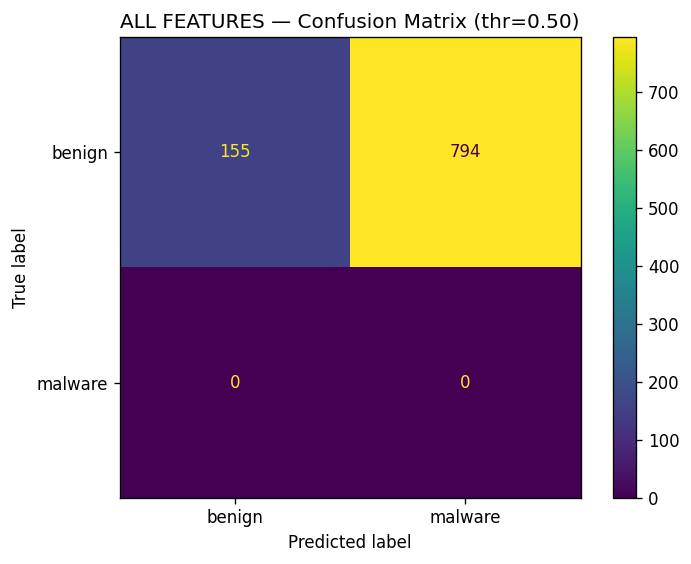

False-positive domains (first 20 of 794):
 • 10bdmbet43.com
 • 11pornxxx.com
 • 123hdd.com
 • 123sss.net
 • 13d0jwj0azfgtb0ipfqp7xm.com
 • 14pg2.com
 • 14pg8.com
 • 168topgameb.com
 • 1hzaqfiu8ctr.com
 • 1x7bet.xyz
 • 2025tiger.net
 • 2588989.com
 • 2aksestukul.pro
 • 2pastoo.com
 • 2wgaming.com
 • 3patticrown.net
 • 42pg10.com
 • 48ninecasino16.com
 • 4iki.net
 • 53pgdd.com


In [10]:
plot_cm(y_true, y_pred, f"ALL FEATURES — Confusion Matrix (thr={THRESHOLD:.2f})")

if "domain_name" in df_fp.columns:
    fp_domains = df_fp.loc[y_pred == 1, "domain_name"].tolist()
    print(f"False-positive domains (first {min(TOP_N_FP_LIST, len(fp_domains))} of {len(fp_domains)}):")
    for d in fp_domains[:TOP_N_FP_LIST]:
        print(" •", d)


## 11. Error analysis — per-feature contributions on false positives

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse: model, X, y_true, proba, y_pred, required from earlier cells

# 1) Get LightGBM contributions (SHAP-like). Shape: (n_samples, n_features + 1 bias)
contrib = model.predict(X, pred_contrib=True)
feature_contrib = contrib[:, :-1]  # drop bias term (last column)

# 2) Focus on *false positives* (true=benign=0, predicted=malware=1)
fp_mask = (y_true == 0) & (y_pred == 1)
fp_count = int(fp_mask.sum())
print(f"False positives: {fp_count}")

# 3) Build a DataFrame for convenience
feat_names = required if required is not None else [f"f{i}" for i in range(feature_contrib.shape[1])]
fp_contrib_df = pd.DataFrame(feature_contrib[fp_mask], columns=feat_names)

# Positive contributions increase the malware score; negatives push to benign.
# We'll aggregate *positive* contributions among FPs to see “what pushed it over.”
pos_fp_contrib = fp_contrib_df.clip(lower=0)

# 4) Rank features: mean positive contribution on FP rows
rank_mean = pos_fp_contrib.mean().sort_values(ascending=False)
top15 = rank_mean.head(15)

print("\nTop 15 features by mean positive contribution on false positives:")
for i, (f, v) in enumerate(top15.items(), 1):
    print(f"{i:2d}. {f}: {v:.6f}")


False positives: 794

Top 15 features by mean positive contribution on false positives:
 1. ip_a_aaaa_to_all_ratio: 2.261365
 2. dns_NS_count: 1.649137
 3. rdap_ip_v4_count: 1.268877
 4. rdap_domain_age: 0.857773
 5. lex_sub_count: 0.824182
 6. lex_tld_abuse_score: 0.798296
 7. rdap_domain_active_time: 0.690881
 8. ip_as_address_entropy: 0.450484
 9. rdap_registrar_name_len: 0.323580
10. rdap_registration_period: 0.227052
11. dns_ttl_stdev: 0.118809
12. tls_CA_certs_in_chain_ratio: 0.118358
13. lex_stdev_part_lens: 0.104441
14. ip_asn_entropy: 0.086594
15. rdap_admin_name_len: 0.073125


## 12. Plot — Top 15 malware-pushing contributors on FP

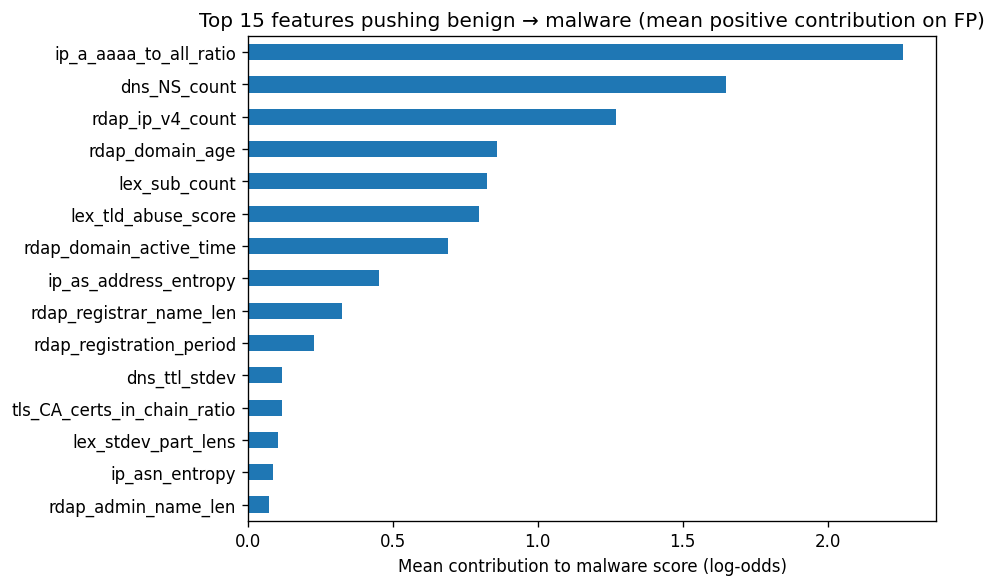

In [12]:
# Horizontal bar plot for readability
plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 features pushing benign → malware (mean positive contribution on FP)")
plt.xlabel("Mean contribution to malware score (log-odds)")
plt.tight_layout()
plt.show()


## 13. Contrast with correct benigns to avoid red herrings


Top 15 features with biggest FP vs TN mean-positive gap:
rdap_domain_age               0.825566
rdap_domain_active_time       0.505742
ip_a_aaaa_to_all_ratio        0.417165
rdap_registrar_name_len       0.293287
rdap_ip_v4_count              0.271443
rdap_registration_period      0.214623
dns_NS_count                  0.204819
lex_tld_abuse_score           0.183824
ip_as_address_entropy         0.154381
rdap_admin_name_len           0.069075
rdap_registrar_name_entropy   0.060103
lex_stdev_part_lens           0.035190
ip_asn_entropy                0.034717
rdap_admin_name_entropy       0.031500
dns_ttl_distinct_count        0.018666


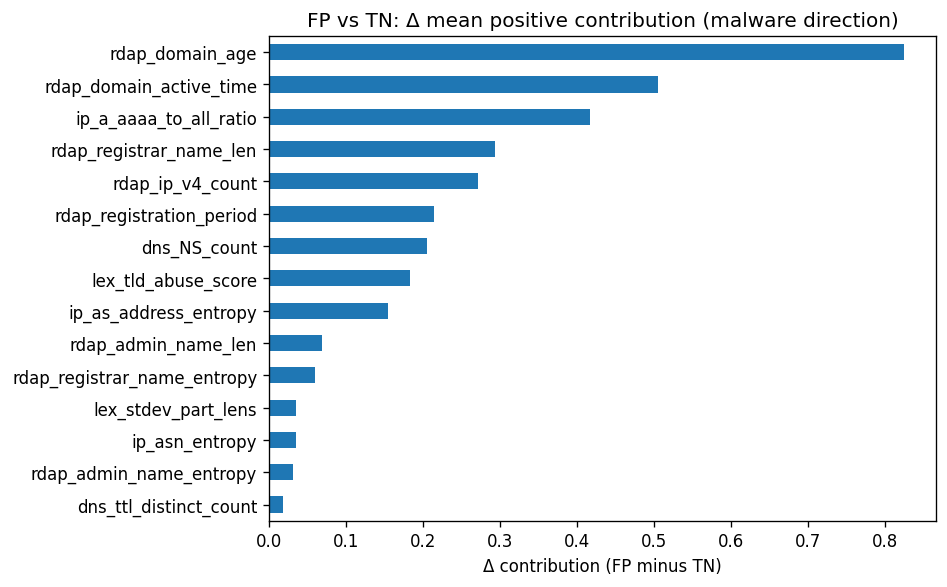

In [13]:
# Compare FP vs TN average contributions — useful to spot features uniquely high in FP
tn_mask = (y_true == 0) & (y_pred == 0)
tn_pos = pd.DataFrame(feature_contrib[tn_mask], columns=feat_names).clip(lower=0)
fp_vs_tn_delta = (pos_fp_contrib.mean() - tn_pos.mean()).sort_values(ascending=False)

print("\nTop 15 features with biggest FP vs TN mean-positive gap:")
print(fp_vs_tn_delta.head(15).to_string(float_format=lambda x: f"{x:.6f}"))

plt.figure(figsize=(8,5))
fp_vs_tn_delta.head(15).sort_values().plot(kind="barh")
plt.title("FP vs TN: Δ mean positive contribution (malware direction)")
plt.xlabel("Δ contribution (FP minus TN)")
plt.tight_layout()
plt.show()
